In [6]:
import scipy.io
import scipy.signal
from fontTools.subset import subset
from scipy.signal import butter,filtfilt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd




#importing mydata
OR = scipy.io.loadmat(r'C:\Users\manis\Documents\Masters\self project\Data\12k_Drive_End_OR007@6_0')
IR = scipy.io.loadmat(r'C:\Users\manis\Documents\Masters\self project\Data\12k_Drive_End_IR007@6_0')
Ball = scipy.io.loadmat(r'C:\Users\manis\Documents\Masters\self project\Data\12k_Drive_End_BA007@6_0')
NOR = scipy.io.loadmat(r'C:\Users\manis\Documents\Masters\self project\Data\normaldata')
##parameters


#Signals & Frequencies
signals = [NOR['X097_DE_time'].ravel(),
           OR['X130_DE_time'].ravel(),
           IR['X278_DE_time'].ravel(),
           Ball['X282_DE_time'].ravel(),
           ]
bearing_data = {
    'pitch_diameter' : 38.5,
    'ball_diameter' : 7.94,
    'n' : 9,
    'phi' : 0,
    'shaft_speed' : 1797

}
fs = 12000
n_samples = min(len(signal) for signal in signals)
time = np.linspace(0,n_samples/fs,n_samples)

In [17]:

def signal_length_matching(sgn):
    min_length = min(len(signal) for signal in sgn)

    for i in range(len(sgn)):
        sgn[i] = sgn[i][:min_length]

    return sgn

def extract_features(sgn,window_size = 1024):
    features = []
    n_windows = len(sgn) // window_size
    trimmed = np.array(sgn[:n_windows * window_size])
    windows = trimmed.reshape(n_windows, window_size)

    for window in windows:
        rms = np.sqrt(np.mean(window**2))
        kurt = scipy.stats.kurtosis(window)
        crest = np.max(window)/rms
        skew = scipy.stats.skew(window)
        peak_to_peak = np.max(window)-np.min(window)
        features.append([rms, kurt,crest, skew, peak_to_peak])

    return np.array(features)

def build_dataset(sgn):
    values = []
    labels = []
    for i in range(len(sgn)):
        my_value = extract_features(sgn[i],window_size=1024)
        values.append(my_value)
        labels.append(np.full(len(values[i]),i))

    all_features = np.vstack(values)
    all_labels = np.concatenate(labels)
    df = pd.DataFrame(all_features,columns=['RMS', 'Kurtosis','Crest_factor','Skewness','Peak_to_Peak'])
    df['Label'] = all_labels

    return df


def window_signal(sgn):
    windowed = []

    for i in range(len(sgn)):
        window = np.hanning(len(sgn[i]))  # create Hann window
        windowed_signal = sgn[i] * window  # apply window
        windowed.append(windowed_signal)

    return windowed


def transform_signals(sgn):
    transformed_signals = []

    for i in range(len(sgn)):
        my_value = np.fft.rfft(sgn[i])
        my_value = my_value / len(sgn[i])
        my_value = np.abs(my_value)
        my_value = np.power(my_value, 2)
        transformed_signals.append(my_value)
    return transformed_signals


def get_frequencies(sgn, fs):
    frequencies = []

    for i in range(len(sgn)):
        my_value = np.fft.rfftfreq(len(sgn[i]), 1 / fs)
        frequencies.append(my_value)

    return frequencies


def apply_filter(sgn, sampling_rate):
    filtered_signals = []
    b, a = butter(4, [3000,5000] , btype='bandpass', fs=sampling_rate)

    for i in range(len(sgn)):
        filtered = filtfilt(b, a, sgn[i])
        filtered_signals.append(filtered)

    return filtered_signals


def char_frequencies(pitch_diameter, ball_diameter, n, phi, fr):
    fr = fr / 60
    bpfo = (n / 2) * fr * (1 - (ball_diameter / pitch_diameter) * np.cos(phi))  ##ballpass frequency, outer race
    bpfi = (n / 2) * fr * (1 + (ball_diameter / pitch_diameter) * np.cos(phi))  ##ballpass frequency, inner race

    bsf = (pitch_diameter / (2 * ball_diameter)) * (
                1 - (np.pow((ball_diameter / pitch_diameter) * np.cos(phi), 2)))  ##ball spin frequency

    ftf = (fr / 2) * (1 - (ball_diameter / pitch_diameter) * np.cos(phi))  ##fundamental train frequency
    my_features = {'BPFO':bpfo,
                   'BPFI':bpfi,
                   'BSF':bsf,
                   'FTF':ftf}

    return my_features


###hilbert+ envelope both is being done with this function
def apply_hilbert(sgn):
    hilbert_signals = []

    for i in range(len(sgn)):
        my_value = scipy.signal.hilbert(sgn[i])
        my_value = np.abs(my_value)
        hilbert_signals.append(my_value)

    return hilbert_signals


In [19]:
Signals = signal_length_matching(signals)
windowed_signal = extract_features(Signals[0],window_size=1024)

df = build_dataset(Signals)
df.to_csv(r"C:\Users\manis\Documents\Masters\self project\Data\data_features\bearing_feature.csv", index=False)

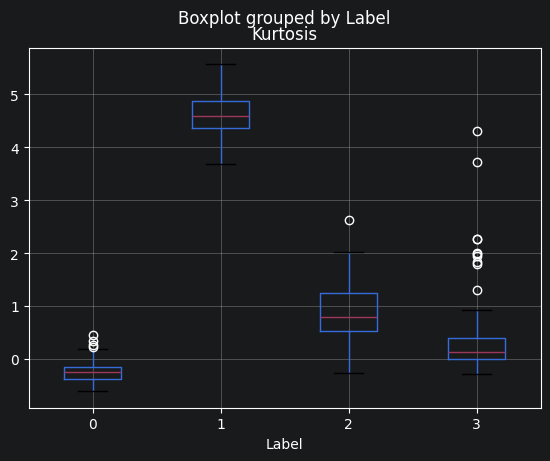

"\ncolors = ['green','red','blue','orange']\nlabels = ['NORMAL','OUTER-RING','INNER-RING','BALL']\n\nfor i in range(4):\n    subset = df[df['Label'] == i]\n    plt.scatter(subset['RMS'],subset['Kurtosis'],color=colors[i],label=labels[i])\nplt.xlabel('RMS')\nplt.ylabel('Kurtosis')\nplt.legend()\nplt.title('RMS vs Kurtosis by fault type')\nplt.show()"

In [30]:
df.boxplot(column='Kurtosis', by='Label')
plt.show()
"""
colors = ['green','red','blue','orange']
labels = ['NORMAL','OUTER-RING','INNER-RING','BALL']

for i in range(4):
    subset = df[df['Label'] == i]
    plt.scatter(subset['RMS'],subset['Kurtosis'],color=colors[i],label=labels[i])
plt.xlabel('RMS')
plt.ylabel('Kurtosis')
plt.legend()
plt.title('RMS vs Kurtosis by fault type')
plt.show()"""